# Imports

In [30]:
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import PIL
import PIL.Image
import os
import pathlib
import math
print(tf.__version__)

2.18.0


In [31]:
# # import kagglehub
# import os
# # Download latest version
# # path = kagglehub.dataset_download("nafin59/monkeypox-skin-lesion-dataset")
# # print("Path to dataset files:", path)
# # path = kagglehub.dataset_download("dipuiucse/monkeypoxskinimagedataset")


# # files = os.listdir('../input/monkeypox-skin-lesion-dataset/Fold1/Fold1/Fold1/Test')
# files = os.listdir('../input/monkeypoxskinimagedataset/Monkeypox Skin Image Dataset')

# print(files)

# Hyper-parameters

In [32]:
batch_size = 32
img_height = 224
img_width = 224
lr_rate = 1e-3
lr_mode = 'cos'
epochs = 30
data_dir = pathlib.Path('/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Augmented Images/Augmented Images/FOLDS_AUG/fold1_AUG/Train').with_suffix('')

# Data preprocessing

In [33]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names
print(class_names)

Found 7518 files belonging to 6 classes.
Using 6015 files for training.
Found 7518 files belonging to 6 classes.
Using 1503 files for validation.
['Chickenpox', 'Cowpox', 'HFMD', 'Healthy', 'Measles', 'Monkeypox']


In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
for image_batch, labels_batch in train_ds:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

## Autotone

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Normalization

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

In [38]:
base_model = keras.applications.ResNet50(
    weights='imagenet',  # Load weights pre-trained on ImageNet.
    input_shape=(img_width, img_height, 3),
    include_top=False)  # Do not include the ImageNet classifier at the top.

In [39]:
base_model.trainable = False

In [40]:
inputs = keras.Input(shape=(img_width, img_height, 3))
x = base_model(inputs, training=False)
x = keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs = keras.layers.Dense(6)(x)

model = keras.Model(inputs, outputs)

In [41]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 7, 7, 512)           │       9,437,696 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,158,278 (126.49 MB)

 Trainable params: 9,570,566 (36.51 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## LR Schedule

In [42]:
def get_lr_callback(batch_size=8, mode='cos', epochs=10, plot=False):
    lr_start, lr_max, lr_min = 5e-5, 6e-6 * batch_size, 1e-5
    lr_ramp_ep, lr_sus_ep, lr_decay = 3, 0, 0.75

    def lrfn(epoch):  # Learning rate update function
        if epoch < lr_ramp_ep: lr = (lr_max - lr_start) / lr_ramp_ep * epoch + lr_start
        elif epoch < lr_ramp_ep + lr_sus_ep: lr = lr_max
        elif mode == 'exp': lr = (lr_max - lr_min) * lr_decay**(epoch - lr_ramp_ep - lr_sus_ep) + lr_min
        elif mode == 'step': lr = lr_max * lr_decay**((epoch - lr_ramp_ep - lr_sus_ep) // 2)
        elif mode == 'cos':
            decay_total_epochs, decay_epoch_index = epochs - lr_ramp_ep - lr_sus_ep + 3, epoch - lr_ramp_ep - lr_sus_ep
            phase = math.pi * decay_epoch_index / decay_total_epochs
            lr = (lr_max - lr_min) * 0.5 * (1 + math.cos(phase)) + lr_min
        return lr

    if plot:  # Plot lr curve if plot is True
        plt.figure(figsize=(10, 5))
        plt.plot(np.arange(epochs), [lrfn(epoch) for epoch in np.arange(epochs)], marker='o')
        plt.xlabel('epoch'); plt.ylabel('lr')
        plt.title('LR Scheduler')
        plt.show()

    return keras.callbacks.LearningRateScheduler(lrfn, verbose=False)  # Create lr callback

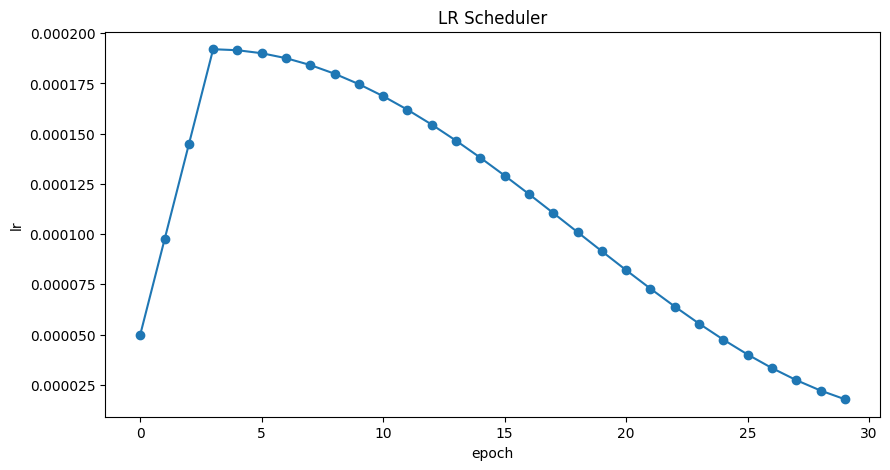

In [43]:
lr_cb = get_lr_callback(batch_size, mode=lr_mode, plot=True, epochs=epochs)

In [44]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr_rate),
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [45]:
history = model.fit(
    train_ds,
    epochs=epochs,
    callbacks=[early_stopping, lr_cb],
    validation_data=train_ds)

Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 45s 170ms/step - accuracy: 0.7047 - loss: 0.8114 - val_accuracy: 0.9185 - val_loss: 0.2377 - learning_rate: 5.0000e-05
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.9134 - loss: 0.2366 - val_accuracy: 0.9490 - val_loss: 0.1569 - learning_rate: 9.7333e-05
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.9494 - loss: 0.1429 - val_accuracy: 0.9465 - val_loss: 0.1464 - learning_rate: 1.4467e-04
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.9455 - loss: 0.1522 - val_accuracy: 0.9433 - val_loss: 0.1700 - learning_rate: 1.9200e-04
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.9637 - loss: 0.1071 - val_accuracy: 0.9729 - val_loss: 0.0693 - learning_rate: 1.9150e-04
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.9790 - loss: 0.0620 - val_accuracy: 0.9822 - val_loss: 0.0507 - learning_rate: 1.9001e-04
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 10

# Evaluation

# Plot training results

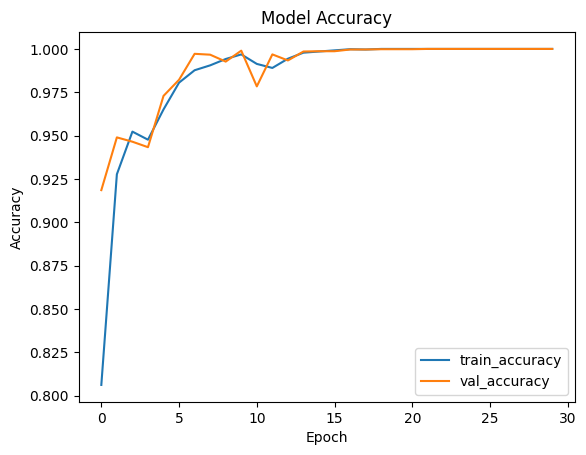

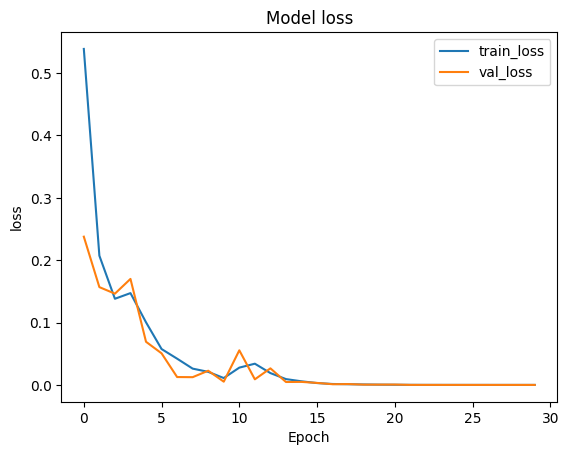

In [46]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train_accuracy', 'val_accuracy'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['train_loss', 'val_loss'])
plt.show()

## Testing

### Test 1

In [47]:
test_data_dir = '/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Original Images/Original Images/FOLDS/fold1/Valid'
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_data_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

model.evaluate(test_ds)

Found 144 files belonging to 6 classes.
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 770ms/step - accuracy: 0.7300 - loss: 1.9726


[2.0516037940979004, 0.7291666865348816]

### Test 2

In [48]:
test_data_dir = '/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Original Images/Original Images/FOLDS/fold1/Test'
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_data_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

model.evaluate(test_ds)

Found 74 files belonging to 6 classes.
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7836 - loss: 1.7572 


[2.026348114013672, 0.7702702879905701]

## Test 3

In [49]:
test_data_dir = '/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Original Images/Original Images/FOLDS/fold2/Valid'
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_data_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

model.evaluate(test_ds)

Found 164 files belonging to 6 classes.
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 327ms/step - accuracy: 0.9847 - loss: 0.0645


[0.10331549495458603, 0.9817073345184326]

## Test 4

In [50]:
test_data_dir = '/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Original Images/Original Images/FOLDS/fold3/Valid'
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_data_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

model.evaluate(test_ds)

Found 153 files belonging to 6 classes.
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 826ms/step - accuracy: 0.9361 - loss: 0.5016


[0.5383946299552917, 0.9346405267715454]

## Test 5

In [51]:
test_data_dir = '/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Original Images/Original Images/FOLDS/fold4/Valid'
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_data_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

model.evaluate(test_ds)

Found 150 files belonging to 6 classes.
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 783ms/step - accuracy: 0.8817 - loss: 1.1257


[0.8202827572822571, 0.9133333563804626]

## Test 5

In [52]:
test_data_dir = '/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Original Images/Original Images/FOLDS/fold5/Valid'
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_data_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

model.evaluate(test_ds)

Found 154 files belonging to 6 classes.
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 418ms/step - accuracy: 0.8963 - loss: 0.8583


[0.7270626425743103, 0.9155844449996948]

# Export and save the model

In [53]:
#Save the entire model
model.save('SkinNet.keras')
#Save training checkpoint
!mkdir checkpoints
model.save_weights('checkpoints/SkinNet.weights.h5')
#Export the model for inference
model.export('export/exported_SkinNet_model')

mkdir: cannot create directory ‘checkpoints’: File exists
Saved artifact at 'export/exported_SkinNet_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_356')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  134392202005200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134392202002704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134392202004624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134392440814288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134392202003280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134392202002512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134392440811792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134388075802704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134388075803280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134388075

# Get in touch
#### Reach me out at:
- Email: [aalrefaei93@gmail.com](mailto:aalrefaei93@gmail.com)
- X: [@guy_997](https://twitter.com/guy_997)
- Instagram: [@guy_997](https://www.instagram.com/guy_997/) 
- Github: [@guy-977](https://github.com/guy-977)
- HuggingFace: [@ahmed-ai](https://huggingface.co/ahmed-ai)
- Telegram: [@guy_997](https://t.me/guy_997)
- Discord: @ahmed.gov